# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Rushil Nanga]

**Date:** [09/02/2028]

In [11]:
# Your Phase 1 solution to the problem goes here.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

airbnb = pd.read_csv("./data/airbnb_hw.csv")
airbnb.loc[
    airbnb["Price"].str.contains(",", na=False),
    "Price"
].head()

airbnb["Price"] = airbnb["Price"].str.replace(",", "", regex=False)
airbnb["Price"] = pd.to_numeric(airbnb["Price"], errors="coerce")

airbnb["Price"].isna().sum()


# In the Price variable, I found that the numbers were being stored as text, which is why numbers over 1000 included a comma. I cleaned the variable by first looking at the values over 1000 and removing the commas. Then, I converted Price to numeric. I used errors="coerce" to classify values that could not be converted into missing values. There were 0 missing values at the end.


np.int64(0)

In [48]:
police["subject_injury"].value_counts(dropna=False)

police["subject_injury"] = police["subject_injury"].where(
    police["subject_injury"].isin(["Yes", "No"])
)

missing_prop = police["subject_injury"].isna().mean()
print(missing_prop)

# I found that around 76.2% of the results are missing. That is a concern because most of the observations in the dataset do not contain information about whether the subject was injured or not.

injury_table = pd.crosstab(
    police["force_type"],
    police["subject_injury"],
    dropna=False
)

injury_table

# After cross tabulationg the subject_injury and the force_type, both Less Lethal and Maximal Restraint Technique only have missing values. Bodily Force, Chemical Irritant, and Taser have large amounts of missing values while Baton, Firearm, and Less Lethal Projectile have very little. This suggests that the amount of missing values is dependent on force_type

0.7619342359767892


subject_injury,No,Yes,NaN
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


In [23]:
shark = pd.read_excel("./data/GSAF5.xls")

shark.shape
shark.columns

shark[["Unnamed: 21", "Unnamed: 22"]].notna().sum()

shark = shark.drop(columns=["Unnamed: 21", "Unnamed: 22"])

shark.shape

(7117, 21)

Minimum year: 5.0
Maximum year: 2026.0


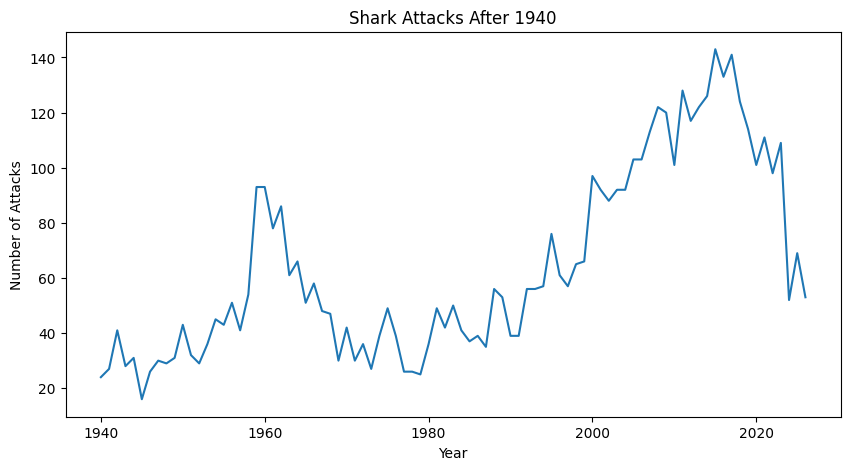

In [33]:
shark["Year"].value_counts(dropna=False).sort_index()

shark["Year"] = pd.to_numeric(
    shark["Year"],
    errors="coerce"
)

shark.loc[shark["Year"] == 0, "Year"] = np.nan

print("Earliest Year:", shark["Year"].min())
print("Recent Year:", shark["Year"].max())

shark_recent = shark[
    shark["Year"] >= 1940
].copy()

len(shark_recent)

attacks_by_year = (
    shark_recent
    .groupby("Year")
    .size()
)

attacks_by_year

plt.figure(figsize=(10, 5))

plt.plot(
    attacks_by_year.index,
    attacks_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.title("Shark Attacks After 1940")

plt.show()

# After cleaning the data, the years range from 5 to 2026. Since 1940, the graph indicates that recorded attacks in general have increased over time, accounting for variation between years.

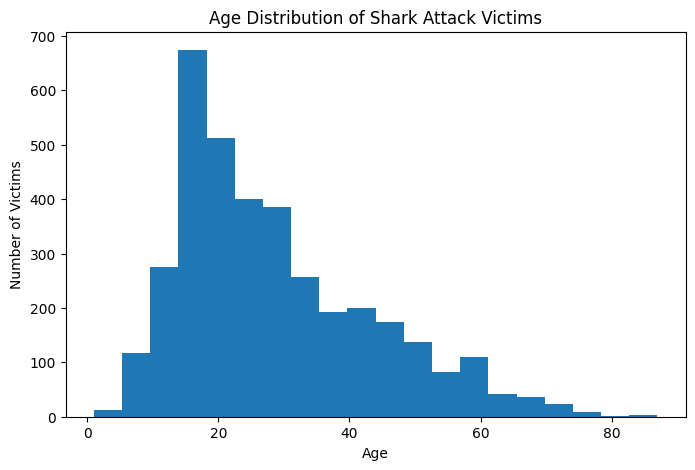

In [37]:
shark_recent["Age"].value_counts(dropna=False).head(30)

shark_recent["Age_clean"] = pd.to_numeric(
    shark_recent["Age"],
    errors="coerce"
)

shark_recent["Age_clean"].describe()

plt.figure(figsize=(8, 5))

plt.hist(
    shark_recent["Age_clean"].dropna(),
    bins=20
)

plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.title("Age Distribution of Shark Attack Victims")

plt.show()

In [49]:
shark_recent["Sex"].value_counts(dropna=False)

shark_recent["Sex_clean"] = (
    shark_recent["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

shark_recent["Sex_clean"] = shark_recent["Sex_clean"].where(
    shark_recent["Sex_clean"].isin(["M", "F"])
)

shark_recent["Sex_clean"].value_counts(dropna=False)

male_prop = (
    shark_recent["Sex_clean"]
    .dropna()
    .eq("M")
    .mean()
)

print(male_prop)

0.8571707317073171


In [50]:
shark_recent["Type"].value_counts(dropna=False)

type_text = (
    shark_recent["Type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

shark_recent["Type_clean"] = type_text.map({
    "provoked": "Provoked",
    "unprovoked": "Unprovoked"
}).fillna("Unknown")

shark_recent["Type_clean"].value_counts()

unprovoked_prop = (
    shark_recent["Type_clean"] == "Unprovoked"
).mean()

print(unprovoked_prop)

0.7459236695932628


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [b62df10]
- **AI tool and model used:** [ChatGPT]

### *Prompts used

1. Review my code and suggest improvements to the cleaning, validation, and explanations while making sure that the results are still correct
2. Give me an updated solution that keeps the code simple but improves on everything

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1) Make the Airbnb Price cleaning more robust by stripping whitespace and dollar signs in addition to removing commas, while preserving the original column and creating a separate cleaned column.
2) Add validation checks for the Airbnb price cleaning, including missing count, minimum, and maximum values.
3) Standardize subject_injury text before keeping only Yes and No, and preserve unknown observations as missing rather than changing them to No.
4) Improve the police missingness analysis by calculating the percentage of missing subject_injury values within each force_type, rather than relying only on raw cross-tab counts.
5) Make the shark Year cleaning more explicit by using a separate cleaned column, converting invalid values to missing, treating year 0 as missing, and then filtering to 1940 onward.
6) Add validation to the shark Age cleaning by retaining only clearly numeric ages in a reasonable range and leaving ambiguous text such as Teen, 30s, or multiple ages as missing.
7) Clarify the denominator used for the male-victim proportion by reporting the percentage among known M/F observations and also checking the proportion among all post-1940 rows.
8) Verify that the cleaned Type variable contains only Provoked, Unprovoked, and Unknown, and confirm the category counts before calculating the unprovoked proportion.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
Change	Decision	Reason and verification
1	Accept	My Phase 1 code handled commas correctly, but stripping whitespace and $ signs makes the cleaning more robust. I also kept the original Price column so I could compare it with the cleaned version.
2	Accept	Checking the missing count and price range makes it easier to verify that the cleaning worked. The cleaned data still had 0 missing values.
3	Accept	Standardizing text first is safer than assuming every valid value is already formatted exactly the same. Missing values should remain missing because they do not mean No.
4	Accept	Raw counts showed a pattern, but percentages by force type make the missingness easier to compare because the force categories have different numbers of observations.
5	Accept	Keeping a separate cleaned Year variable makes the cleaning easier to verify and avoids overwriting the original values.
6	Accept	I kept only clearly numeric ages and used a reasonable age range. I did not try to guess exact ages from ambiguous values such as Teen, 30s, or multiple ages.
7	Accept	The denominator affects the result, so explicitly stating that 85.72% is among known M/F observations makes the answer clearer.
8	Accept	Checking the final categories verifies that the Type variable was actually reduced to the three requested values.

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [52]:
# Your Phase 2 solution to the problem goes here.
airbnb = pd.read_csv("./data/airbnb_hw.csv")

airbnb["Price_clean"] = (
    airbnb["Price"]
    .astype("string")
    .str.strip()
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

airbnb["Price_clean"] = pd.to_numeric(
    airbnb["Price_clean"],
    errors="coerce"
)

print("Missing values:", airbnb["Price_clean"].isna().sum())
print("Minimum price:", airbnb["Price_clean"].min())
print("Maximum price:", airbnb["Price_clean"].max())

airbnb.loc[
    airbnb["Price"].astype("string").str.contains(",", na=False),
    ["Price", "Price_clean"]
].head()

Missing values: 0
Minimum price: 10
Maximum price: 10000


,Price,Price_clean
101,"1,990",1990
263,"1,000",1000
764,"1,200",1200
1272,"1,000",1000
1275,"5,000",5000


In [53]:
police = pd.read_csv("./data/mn_police_use_of_force.csv")

injury_text = (
    police["subject_injury"]
    .astype("string")
    .str.strip()
    .str.title()
)

police["subject_injury_clean"] = injury_text.where(
    injury_text.isin(["Yes", "No"])
)

missing_prop = police["subject_injury_clean"].isna().mean()

print("Missing proportion:", missing_prop)
print("Missing percent:", missing_prop * 100)

injury_table = pd.crosstab(
    police["force_type"],
    police["subject_injury_clean"],
    dropna=False
)

print(injury_table)

force_missing = (
    police
    .assign(
        injury_missing=police["subject_injury_clean"].isna()
    )
    .groupby("force_type")["injury_missing"]
    .agg(["sum", "count", "mean"])
)

force_missing["missing_percent"] = force_missing["mean"] * 100

force_missing

Missing proportion: 0.7619342359767892
Missing percent: 76.19342359767892
subject_injury_clean           No   Yes  <NA>
force_type                                   
Baton                           0     2     2
Bodily Force                 1093  1286  7051
Chemical Irritant             131    41  1421
Firearm                         2     0     0
Gun Point Display              33    44    27
Improvised Weapon              34    40    74
Less Lethal                     0     0    87
Less Lethal Projectile          1     2     0
Maximal Restraint Technique     0     0   170
Police K9 Bite                  2    44    31
Taser                         150   172   985


,sum,count,mean,missing_percent
force_type,,,,
Baton,2,4,0.500000,50.000000
Bodily Force,7051,9430,0.747720,74.772004
Chemical Irritant,1421,1593,0.892028,89.202762
Firearm,0,2,0.000000,0.000000
Gun Point Display,27,104,0.259615,25.961538
Improvised Weapon,74,148,0.500000,50.000000
Less Lethal,87,87,1.000000,100.000000
Less Lethal Projectile,0,3,0.000000,0.000000
Maximal Restraint Technique,170,170,1.000000,100.000000


In [54]:
shark = pd.read_excel("./data/GSAF5.xls")

print("Original shape:", shark.shape)
print(shark.columns)

print(
    shark[["Unnamed: 21", "Unnamed: 22"]]
    .notna()
    .sum()
)

shark = shark.drop(
    columns=["Unnamed: 21", "Unnamed: 22"]
)

print("New shape:", shark.shape)

Original shape: (7117, 23)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')
Unnamed: 21    1
Unnamed: 22    2
dtype: int64
New shape: (7117, 21)


Minimum year: 5.0
Maximum year: 2026.0
Missing years: 131
Rows since 1940: 5581


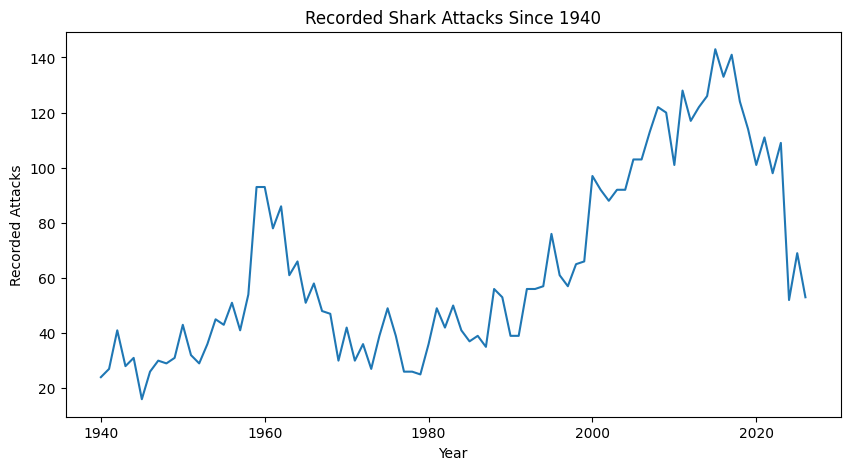

In [55]:
shark["Year_clean"] = pd.to_numeric(
    shark["Year"],
    errors="coerce"
)

shark.loc[
    shark["Year_clean"] == 0,
    "Year_clean"
] = np.nan

print("Minimum year:", shark["Year_clean"].min())
print("Maximum year:", shark["Year_clean"].max())
print("Missing years:", shark["Year_clean"].isna().sum())

shark_recent = shark.loc[
    shark["Year_clean"] >= 1940
].copy()

print("Rows since 1940:", len(shark_recent))

attacks_by_year = (
    shark_recent
    .groupby("Year_clean")
    .size()
)

plt.figure(figsize=(10, 5))
plt.plot(
    attacks_by_year.index,
    attacks_by_year.values
)

plt.xlabel("Year")
plt.ylabel("Recorded Attacks")
plt.title("Recorded Shark Attacks Since 1940")
plt.show()

Age
NaN    1777
16       80
19       80
17       79
15       76
18       74
20       73
17       72
20       67
25       66
15       65
21       64
22       64
18       63
24       58
14       57
19       57
16       56
21       56
24       52
14       52
22       51
26       51
12       49
13       48
25       48
28       47
29       47
13       46
26       44
Name: count, dtype: int64
count       3645.0
mean     28.638409
std      14.843747
min            1.0
25%           17.0
50%           25.0
75%           38.0
max           87.0
Name: Age_clean, dtype: Float64


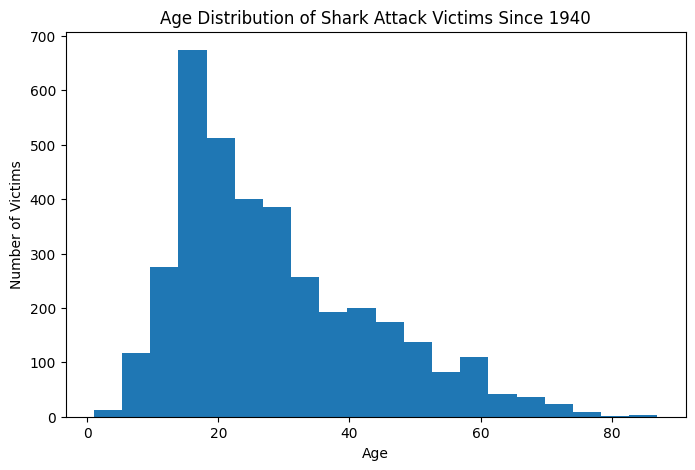

In [56]:
print(
    shark_recent["Age"]
    .value_counts(dropna=False)
    .head(30)
)

shark_recent["Age_clean"] = pd.to_numeric(
    shark_recent["Age"]
    .astype("string")
    .str.strip(),
    errors="coerce"
)

shark_recent["Age_clean"] = shark_recent["Age_clean"].where(
    shark_recent["Age_clean"].between(0, 100)
)

print(shark_recent["Age_clean"].describe())

plt.figure(figsize=(8, 5))
plt.hist(
    shark_recent["Age_clean"].dropna(),
    bins=20
)

plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.title("Age Distribution of Shark Attack Victims Since 1940")
plt.show()

In [57]:
sex_text = (
    shark_recent["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

shark_recent["Sex_clean"] = sex_text.where(
    sex_text.isin(["M", "F"])
)

print(
    shark_recent["Sex_clean"]
    .value_counts(dropna=False)
)

male_prop_known = (
    shark_recent["Sex_clean"]
    .dropna()
    .eq("M")
    .mean()
)

male_prop_all = (
    shark_recent["Sex_clean"]
    .eq("M")
    .fillna(False)
    .mean()
)

print("Male proportion among known M/F:", male_prop_known)
print("Male proportion among all rows:", male_prop_all)

Sex_clean
M       4393
F        732
<NA>     456
Name: count, dtype: Int64
Male proportion among known M/F: 0.8571707317073171
Male proportion among all rows: 0.787134922056979


In [58]:
type_text = (
    shark_recent["Type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

shark_recent["Type_clean"] = (
    type_text
    .map({
        "provoked": "Provoked",
        "unprovoked": "Unprovoked"
    })
    .fillna("Unknown")
)

print(
    shark_recent["Type_clean"]
    .value_counts()
)

print(
    shark_recent["Type_clean"]
    .unique()
)

unprovoked_prop = (
    shark_recent["Type_clean"] == "Unprovoked"
).mean()

print("Unprovoked proportion:", unprovoked_prop)

Type_clean
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64
['Unprovoked' 'Provoked' 'Unknown']
Unprovoked proportion: 0.7459236695932628


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]